In [78]:
from dotenv import load_dotenv

load_dotenv()

True

In [90]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore
from langchain_ollama import ChatOllama

from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

In [80]:
# Document Loader
loader = PyPDFLoader("./../sample.pdf")
docs = loader.load()

# Split - Chunks
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
docs = splitter.split_documents(docs)

# Embeddings and vector DB
embeddings = OllamaEmbeddings(model="qwen3-embedding")
vector_store = InMemoryVectorStore.from_documents(documents=docs, embedding=embeddings)

In [81]:
llm = ChatOllama(model="gemma4:31b-cloud")

In [82]:
class RagState(BaseModel):
    question: str = Field(description="User Question")
    documents: list = []
    context: str = Field(default="", description="Context data for user questions")
    answer: str = Field(default="", description="User answer")

In [83]:
# question -> retrieve -> context -> generate


def retrieve_node(state: RagState) -> RagState:
    docs = vector_store.similarity_search(query=state.question)
    state.documents = docs
    return state


def create_context(state: RagState) -> RagState:
    context = ""
    for doc in state.documents:
        context += doc.page_content + "\n\n"

    state.context = context
    return state


def generate_node(state: RagState) -> RagState:
    prompt = f""" You are a assistant and provide the answer for user question based on the provided context,
      Context is : {state.context},
      Question is : {state.question}
    """
    res = llm.invoke(prompt)
    state.answer = res.content
    return state

In [84]:
graph = StateGraph(RagState)

graph.add_node("retrieve_node", retrieve_node)
graph.add_node("create_context", create_context)
graph.add_node("generate_node", generate_node)

graph.add_edge(START, "retrieve_node")
graph.add_edge("retrieve_node", "create_context")
graph.add_edge("create_context", "generate_node")
graph.add_edge("generate_node", END)

graph = graph.compile()

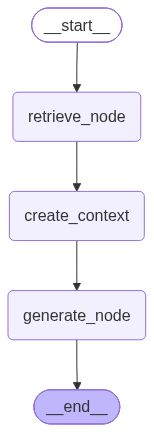

In [85]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())

In [ ]:
res = graph.invoke({"question": "Can slow and steady wins the race?"})

In [88]:
res["answer"]

'Based on the provided text, the answer is yes, in the sense that valuing slow progress provides a "Quiet Advantage."\n\nThe text explains that those who value slow progress become less dependent on immediate rewards, can keep moving even when motivation fades, and can improve without comparing themselves to others. It describes slow progress as "ambition with patience," noting that meaningful growth—like judgment, discipline, and character—often develops quietly and invisibly, similar to a tree building roots before it grows toward the sky. Ultimately, the text suggests that "ordinary days, repeated well, become extraordinary lives."'